In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits


import sys
libpath = Path('./')
sys.path.insert(0, str(libpath))
from samplesreader import SampleFile

pd.set_option('display.precision', 6)


In [57]:

RES_PATH = Path('/Volumes/Codes/example/hmi')
RES_PATH = Path('/Volumes/Codes/example/hinode')

RESULT_PATH = RES_PATH / 'inversion_result.fits'


In [58]:


with fits.open(RESULT_PATH) as hdus:

  if len(hdus) < 2:
    raise ValueError('Result FITS must contain BEST_FIT and PARAMETER_ERROR HDUs')
  
  best_fit = hdus[0].data

  error_lower = hdus[1].data[..., 0]
  error_upper = hdus[1].data[..., 1]

  errors = 0.5*(error_lower+error_upper)
  
  print(best_fit.shape, errors.shape)


(100, 100, 10) (100, 100, 9)


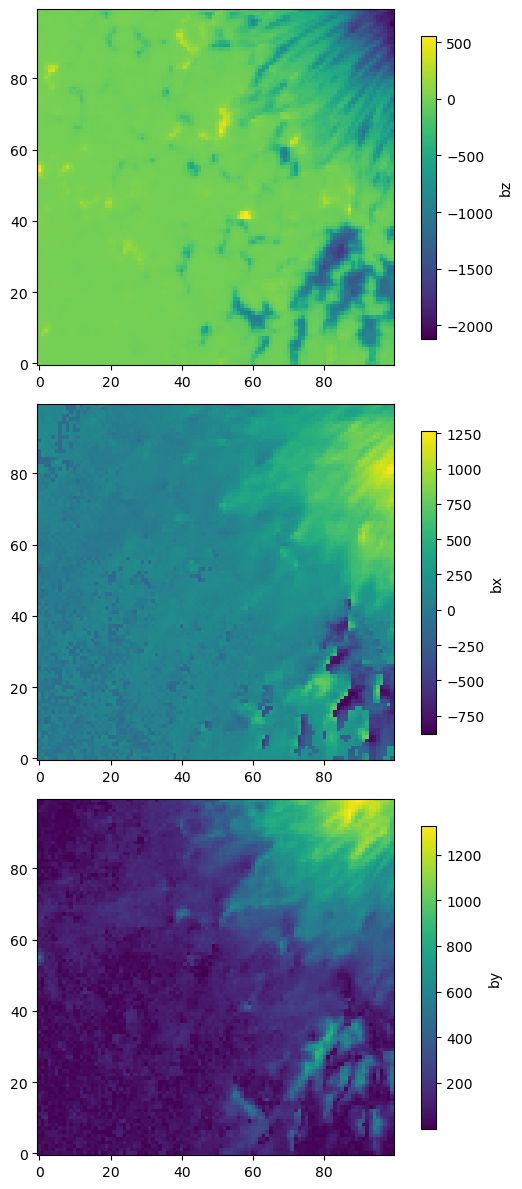

In [59]:

fig, axes = plt.subplots(3,1, figsize=(6, 12))

mp1 = axes[0].imshow(best_fit[..., 0], cmap='viridis', origin='lower')
mp2 = axes[1].imshow(best_fit[..., 1], cmap='viridis', origin='lower')
mp3 = axes[2].imshow(best_fit[..., 2], cmap='viridis', origin='lower')

fig.colorbar(mp1, ax=axes[0], shrink=0.85, label='bz')
fig.colorbar(mp2, ax=axes[1], shrink=0.85, label='bx')
fig.colorbar(mp3, ax=axes[2], shrink=0.85, label='by')

fig.tight_layout()
plt.show()


In [ ]:

SAMPLE_PATH = RES_PATH / 'Samples.bin'
sample_file = SampleFile(SAMPLE_PATH)


In [ ]:

PIXEL = [60, 60]                # x, y in the original observation

samples = sample_file.read_pixel(PIXEL[0], PIXEL[1])
print(f'Pixel {PIXEL}: {len(samples):,} samples, {samples.shape[1]} parameters')


Pixel (60, 60): 70,000 samples, 3 parameters


In [24]:

summary = pd.DataFrame({
    'mean': samples.mean(),
    'std': samples.std(ddof=1),
    'median': samples.median(),
    'q16': samples.quantile(0.15865525393145707),
    'q84': samples.quantile(0.8413447460685429),
    'min': samples.min(),
    'max': samples.max(),
})
summary


,mean,std,median,q16,q84,min,max
Bz,-31.214771,0.761112,-31.202753,-31.971643,-30.449099,-34.667461,-28.611141
Bx,227.315369,2.689649,227.342575,224.565308,229.948807,216.114578,237.235275
By,258.235809,2.623673,258.275879,255.582199,260.896952,249.303574,268.947083


In [ ]:
RESULT_PARAMETERS = None       # example: ['Bz', 'Bx', 'By', 'Vlos']; None plots all
RESULT_ORIGIN = (0, 0)         # (x_begin, y_begin) of sol_box in the observation
CORNER_PARAMETERS = None       # example: ['Bz', 'Bx', 'By', 'Vlos']
CORNER_MAX_SAMPLES = 20_000

In [36]:
print(samples.columns)

Index(['Bz', 'Bx', 'By'], dtype='str')


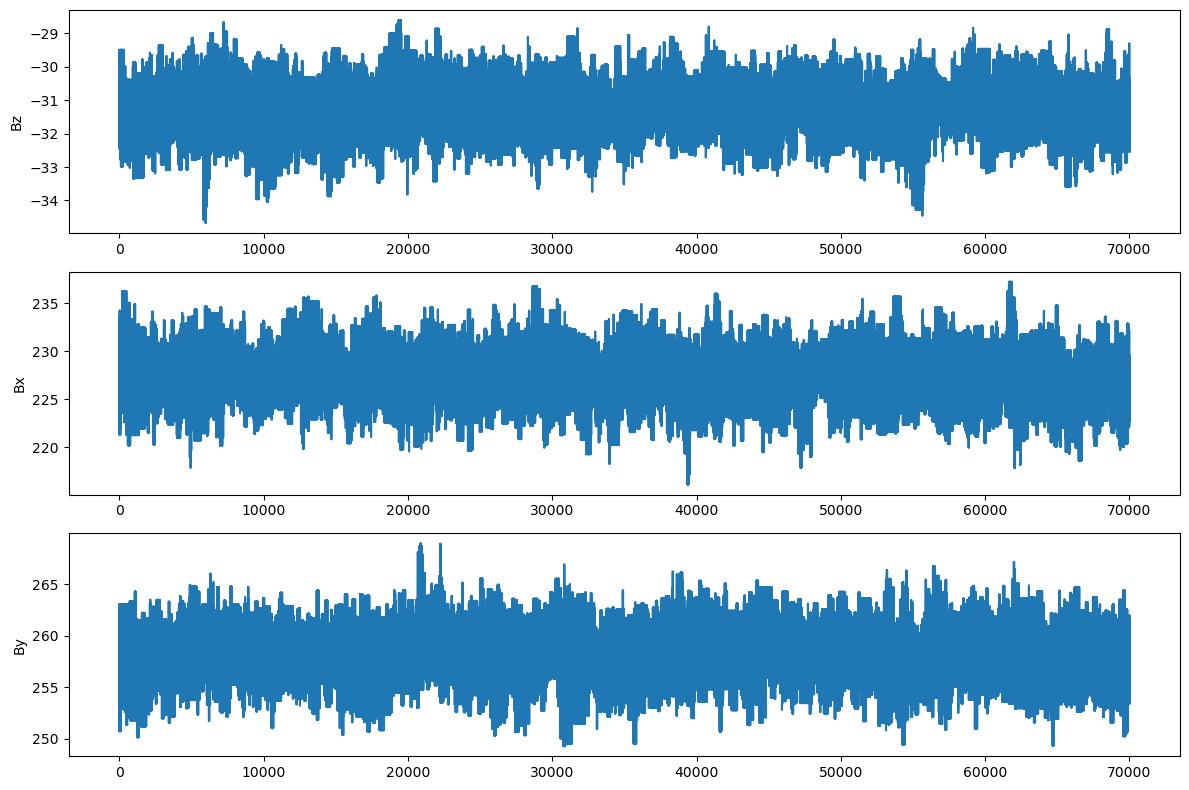

In [39]:
nparams = samples.shape[1]
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(samples.index, samples['Bz'])
axes[1].plot(samples.index, samples['Bx'])
axes[2].plot(samples.index, samples['By'])

axes[0].set_ylabel('Bz')
axes[1].set_ylabel('Bx')
axes[2].set_ylabel('By')

fig.tight_layout()
plt.show()

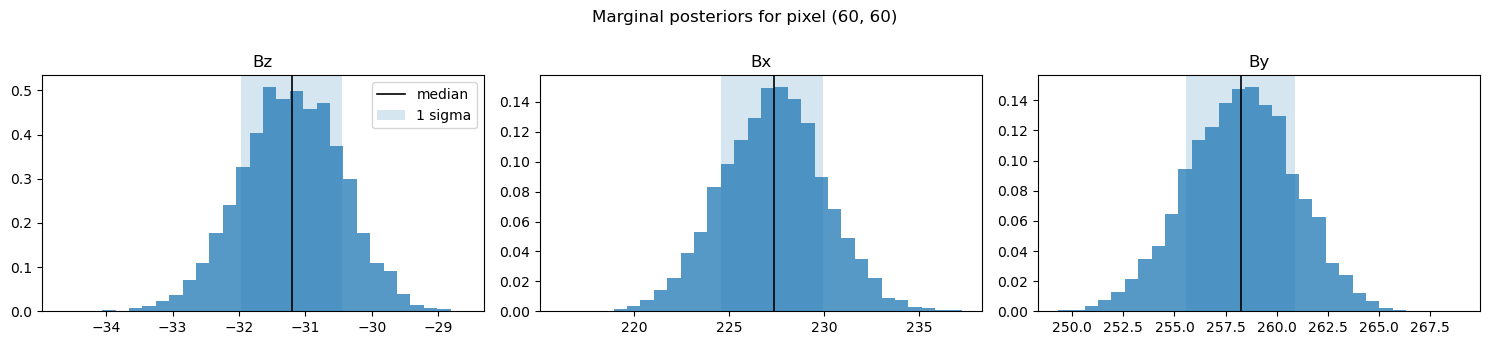

In [43]:
ncols = min(3, samples.shape[1])
nrows = int(np.ceil(samples.shape[1]/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.4*nrows))
for ax, name in zip(axes.flat, samples.columns):
    values = samples[name].to_numpy()
    ax.hist(values, bins=30, density=True, alpha=0.75)
    ax.axvline(np.median(values), color='black', lw=1.2, label='median')
    ax.axvspan(np.quantile(values, 0.15865525393145707),
               np.quantile(values, 0.8413447460685429), alpha=0.18, label='1 sigma')
    ax.set_title(name)
for ax in axes.flat[samples.shape[1]:]:
    ax.remove()
axes.flat[0].legend()
fig.suptitle(f'Marginal posteriors for pixel {PIXEL}', y=1.0)
fig.tight_layout()
plt.show()

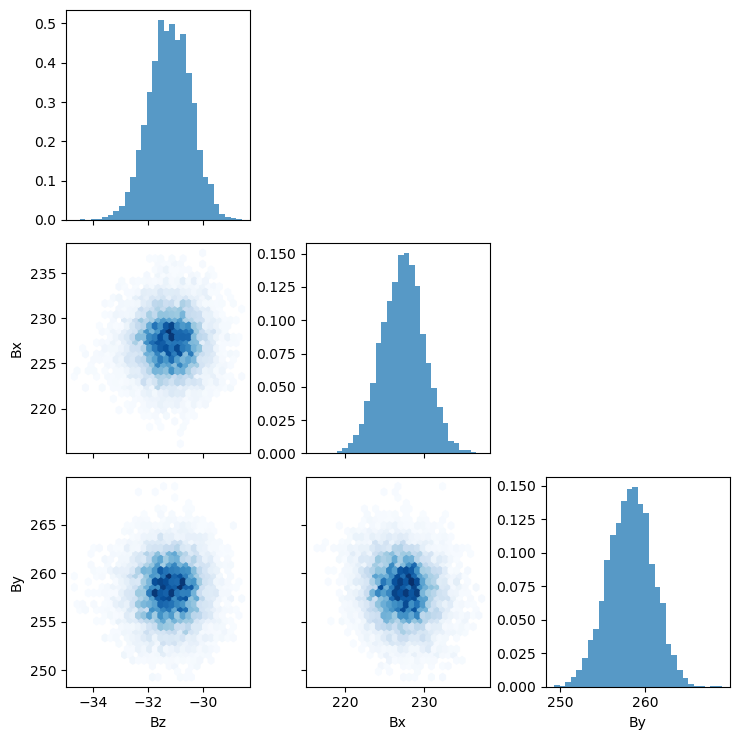

In [47]:

corner_names = list(samples.columns[:min(6, samples.shape[1])])


corner = samples[corner_names]

n = len(corner_names)

fig, axes = plt.subplots(n, n, figsize=(2.5*n, 2.5*n), squeeze=False)
for row in range(n):
  for col in range(n):
    ax = axes[row, col]
    if row == col:
      ax.hist(corner.iloc[:, col], bins=30, density=True, 
              color='tab:blue', alpha=0.75)
    elif row > col:
      ax.hexbin(corner.iloc[:, col], corner.iloc[:, row], gridsize=30, 
                mincnt=1, cmap='Blues')
    else:
      ax.axis('off')

    if row == n-1 and col <= row:
      ax.set_xlabel(corner_names[col])
    else:
      ax.tick_params(labelbottom=False)

    if col == 0 and row > 0:
      ax.set_ylabel(corner_names[row])
    elif row != col:
      ax.tick_params(labelleft=False)

fig.tight_layout()
plt.show()